
## MACHINE LEARNING IN FINANCE
MODULE 2 | LESSON 2


---

# **HIERARCHICAL CLUSTERING**

|  |  |
|:---|:---|
|**Reading Time** |  70 minutes |
|**Prior Knowledge** | Clustering, unsupervised  |
|**Keywords** |dendrogram, hierarchical  |


---

*In the previous lesson, we explored unsupervised machine learning and saw how it differs from supervised machine learning. We also studied different clustering techniques like the k-means algorithm to find patterns in a dataset. In this lesson, we will go further using hierarchical clustering and implement it in clustering foreign exchange rates.*

## **1. Introduction**

Hierarchical  clustering is an unsupervised learning model that clusters data points into hierarchies. In the last lesson, we saw how the k-means algorithm operates, and one of its limitation was that we need to know the number of clusters beforehand. In hierarchical clustering, it is not necessary to know the number of clusters before the modeling process can begin.

Hierarchical clustering can be divided into two types:
1. Agglomerative hierarchical clustering
2. Divisive hierarchical clustering

## **2. Agglomerative Hierarchical Clustering**

Agglomerative hierarchical clustering is the most widely used (in the hierarchical family) to cluster data points based on their similarity. It uses a bottom-up approach where each data point starts as an individual cluster, and at each iteration, similar clusters are merged as we move up the hierarchy until we obtain one cluster or we identify K clusters.

### **2.1 Algorithm**

1. Assume we have the dataset scattered in a two dimensional plane.

2. Each data point forms its own cluster at the beginning.


3. Similar clusters are merged.


4. Repeat step 2 above until a single cluster or K clusters remain(s).


Two clusters are considered similar if the distance between them is small.


### **2.2 Measures of Distance (Similarity)**

Euclidean distance is defined as the distance between two points in a straight line. For example, if $(x_1, y_1)$ and $(x_2, y_2)$ are the points in a 2-dimensional space, then the Euclidean distance would be 
$$\text{Euclidean Distance} = (x_2-x_1)^2 + (y_2 - y_1)^2$$.
Euclidean Distance is applied when the variables are continuous.

Other methods of measuring distance between two points include;

- Hamming distance

We use hamming distance for text and non-numerical data, and it works by counting the number of times the coordinates in the two sets differ.
- Manhattan distance

Manhattan distance is suitable when finding the distance between different locations like finding the distance between schools. It is given by $$|a-b|_1 = \sum_i |a_i - b_i|$$

- Minkowski distance

Minkowski distance is given by $$\left(\sum_{i=1}^n |X_i - Y_i|^p\right)^{1/p}$$
When $p=1$ the Minkowski distance is equivalent to Manhattan distance, for $p=2$ the Minkowski distance is equivalent to Euclidean distance.
- Maximum distance

Maximum distance is the maximum distance we can get between two sets, that is, $$|a-b|_{\infty} = \max_i |a_i - b_i|$$
- Canberra distance

Canberra distance is expressed as $$\sum_i \frac{|x_i - y_i|}{|x_i + y_i|}$$
and terms where the denominator is zero are omitted. Canberra distance is used to compare ranked lists.

The choice of distance metric to use depends on the problem we are trying to solve.

### **2.3 Linkage Criterion**
 
Once we have settled on a distance metric to apply, we need to decide where the distance will be computed. This is referred to as **linkage**.

The commonly used linkage methods are:

 **1. Single linkage / nearest linkage:**

This is the minimum distance between a pair of data points in two different clusters given by
$$d(u,v) = \min(dist(u[i], v[j]))$$ for data points $i$ in cluster $u$ and data points $j$ in cluster $v$. Consider the example below

In [1]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

X = [[i] for i in [2, 8, 0, 4, 1, 9, 9, 0]]

From the given dataset, we obtain a single linkage using the code below.

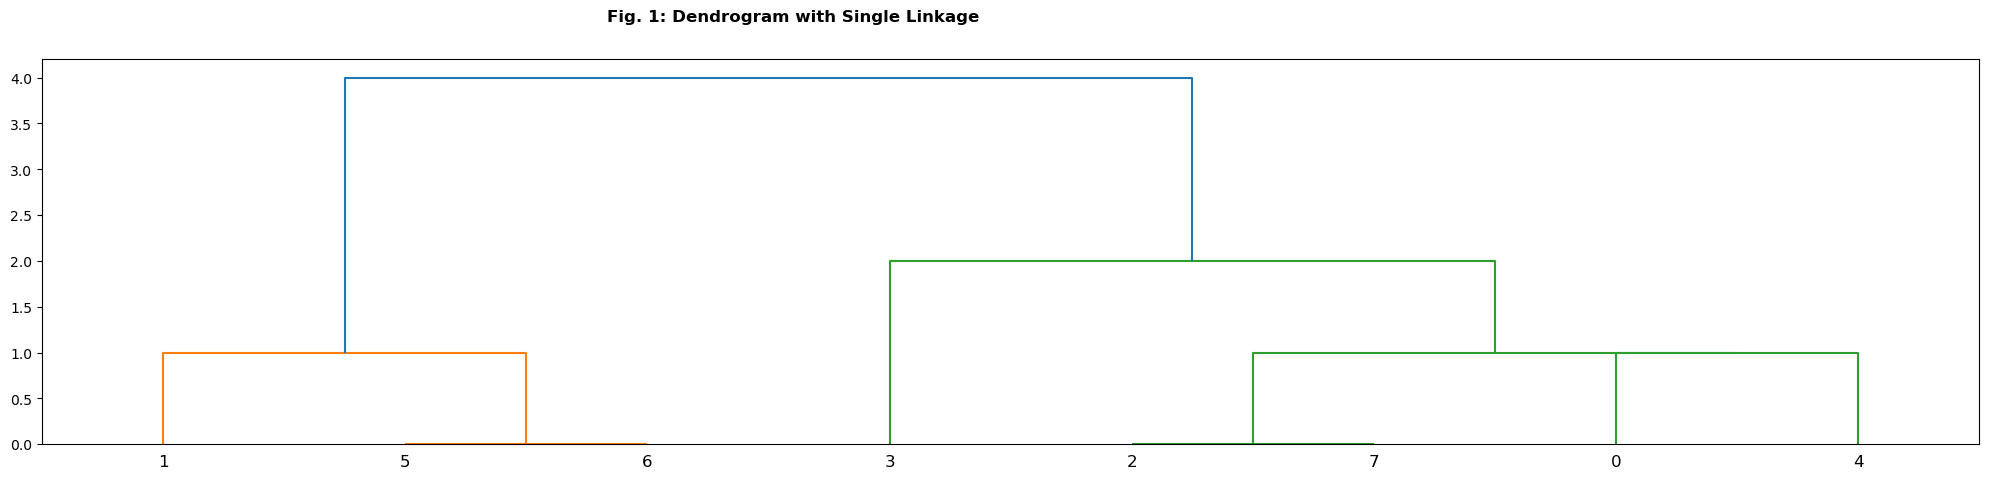

In [2]:
Z = linkage(X, "single")
fig = plt.figure(figsize=(25, 5))
plt.suptitle(
    "Fig. 1: Dendrogram with Single Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)

**2. Complete Linkage:**

This is the maximum distance we can get between data points in two different clusters. The mathematical representation for this is $$d(u,v) = \max(dist(u[i], v[j]))$$ for data points $i$ in cluster $u$ and data points $j$ in cluster $v$. We define the complete linkage in a code as shown below:

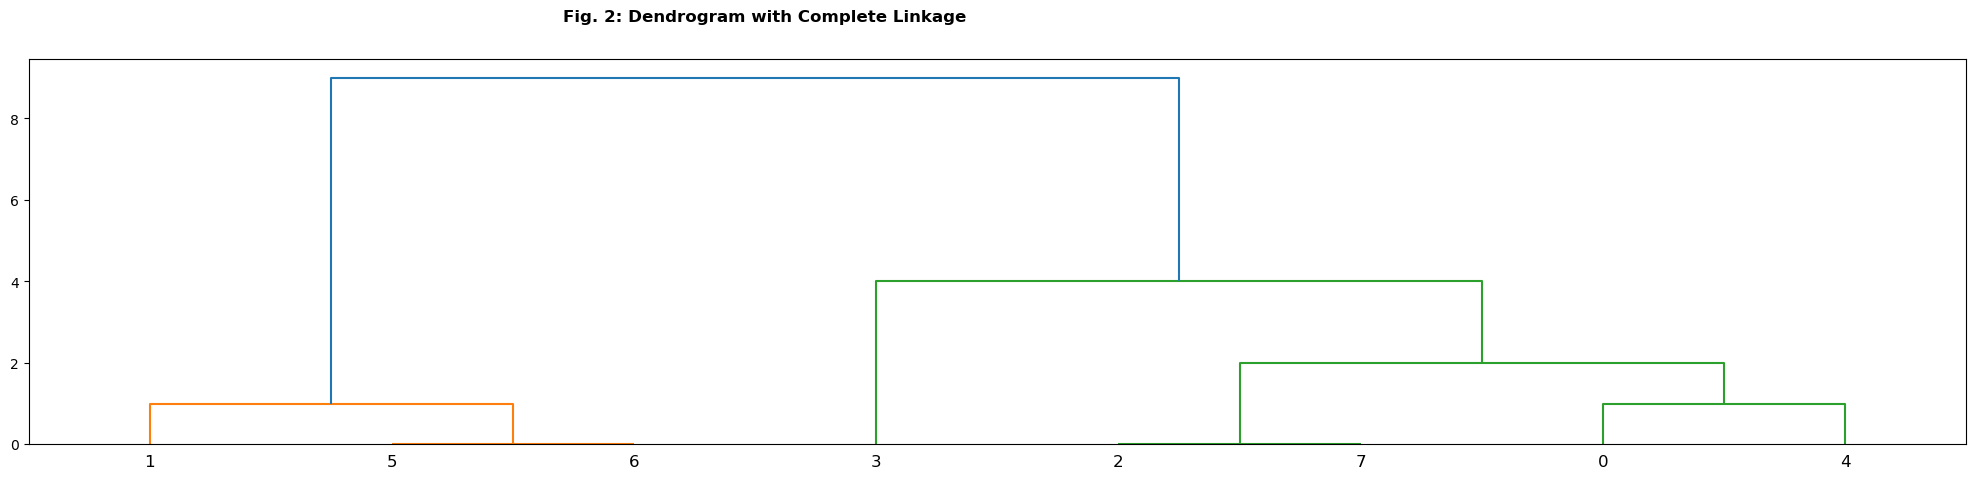

In [3]:
Z = linkage(X, "complete")
fig = plt.figure(figsize=(25, 5))
plt.suptitle(
    "Fig. 2: Dendrogram with Complete Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)


**3. Average Linkage**: 

This is the average of the distance between each data point in one cluster to the data point in the next cluster. Its mathematical representation is as shown below
$$d(u,v) = \sum_{i,j}\frac{d(u[i],v[j])}{(|u|\times|v|)}$$

and just like the two linkages above we specify linkage as average in python code.



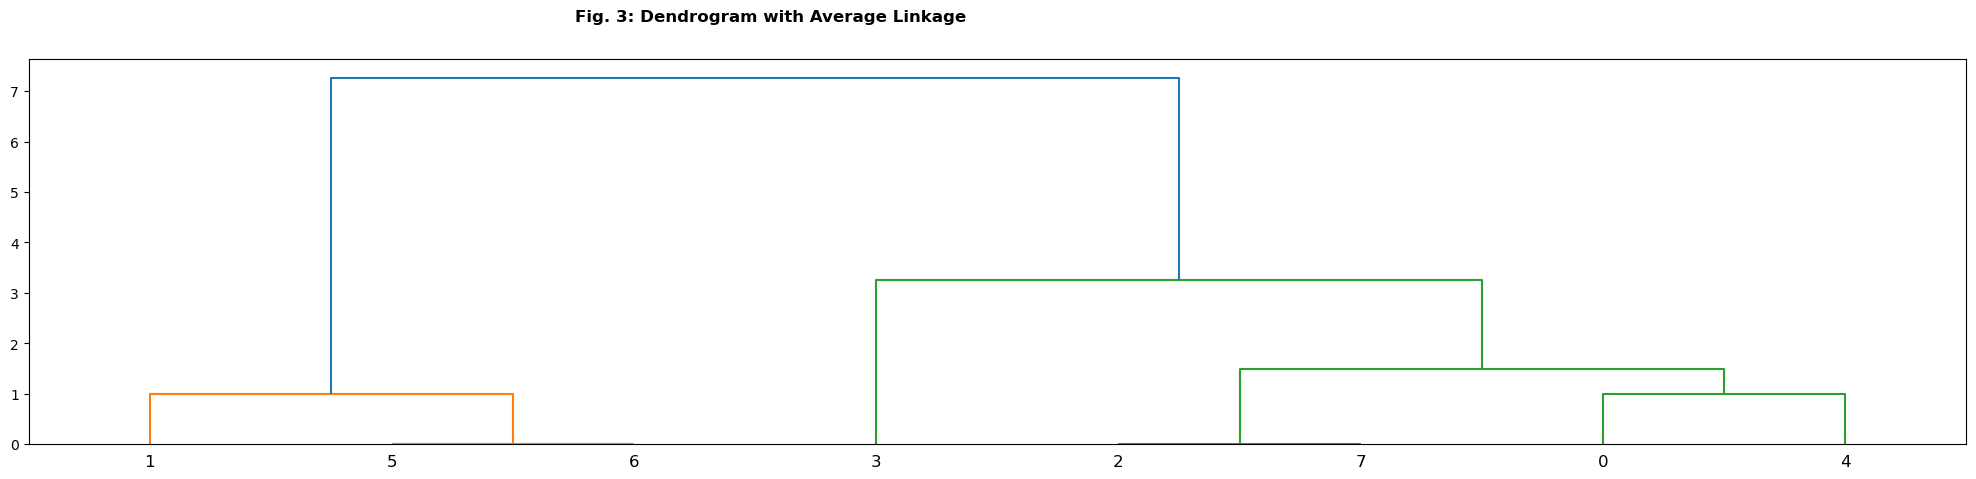

In [4]:
Z = linkage(X, "average")
fig = plt.figure(figsize=(25, 5))
plt.suptitle(
    "Fig. 3: Dendrogram with Average Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)


**4.  Centroid Linkage**: 

This is the distance between the cluster centers and is given by $$d(u,v) = ||c_u - c_v||_2$$ with the linkage specified as in the preceding charts.


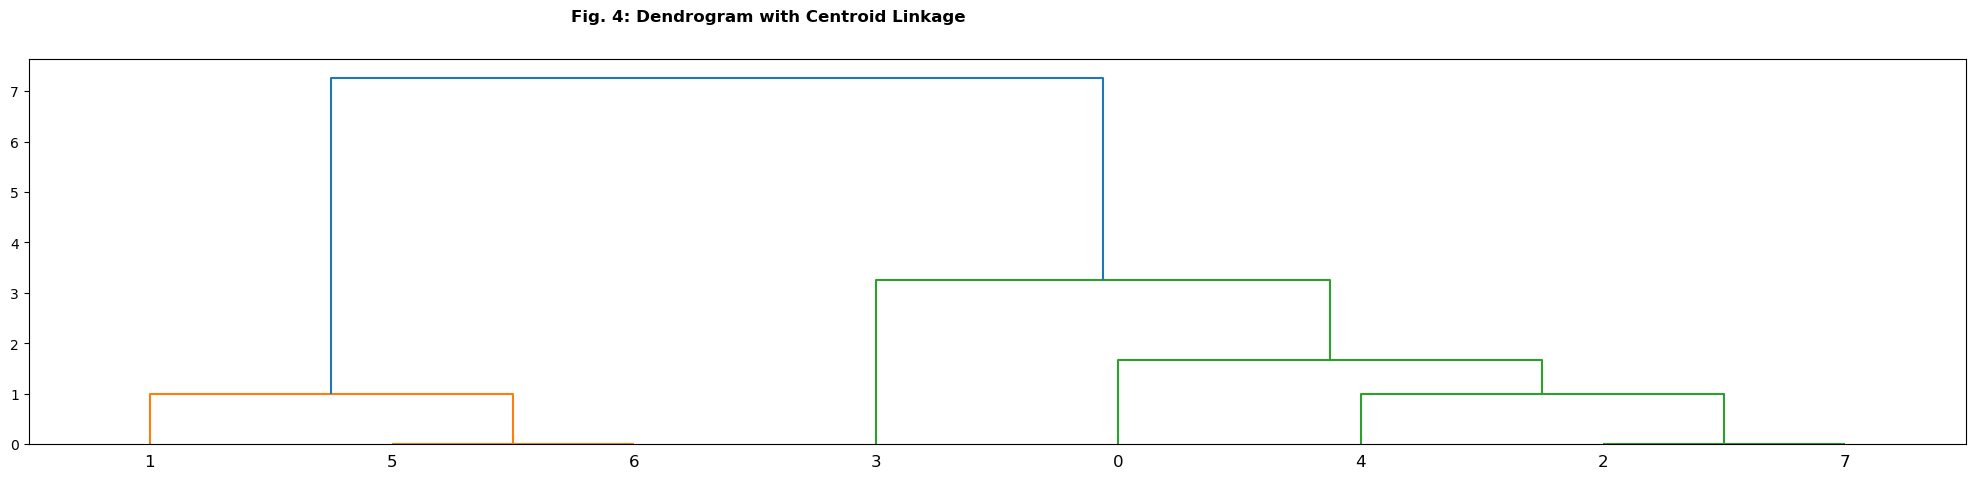

In [5]:
Z = linkage(X, "centroid")
fig = plt.figure(figsize=(25, 5))
plt.suptitle(
    "Fig. 4: Dendrogram with Centroid Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)


**5. Ward's Linkage**: 

Ward's linkage minimizes the increase in the sum of square error at each iteration.

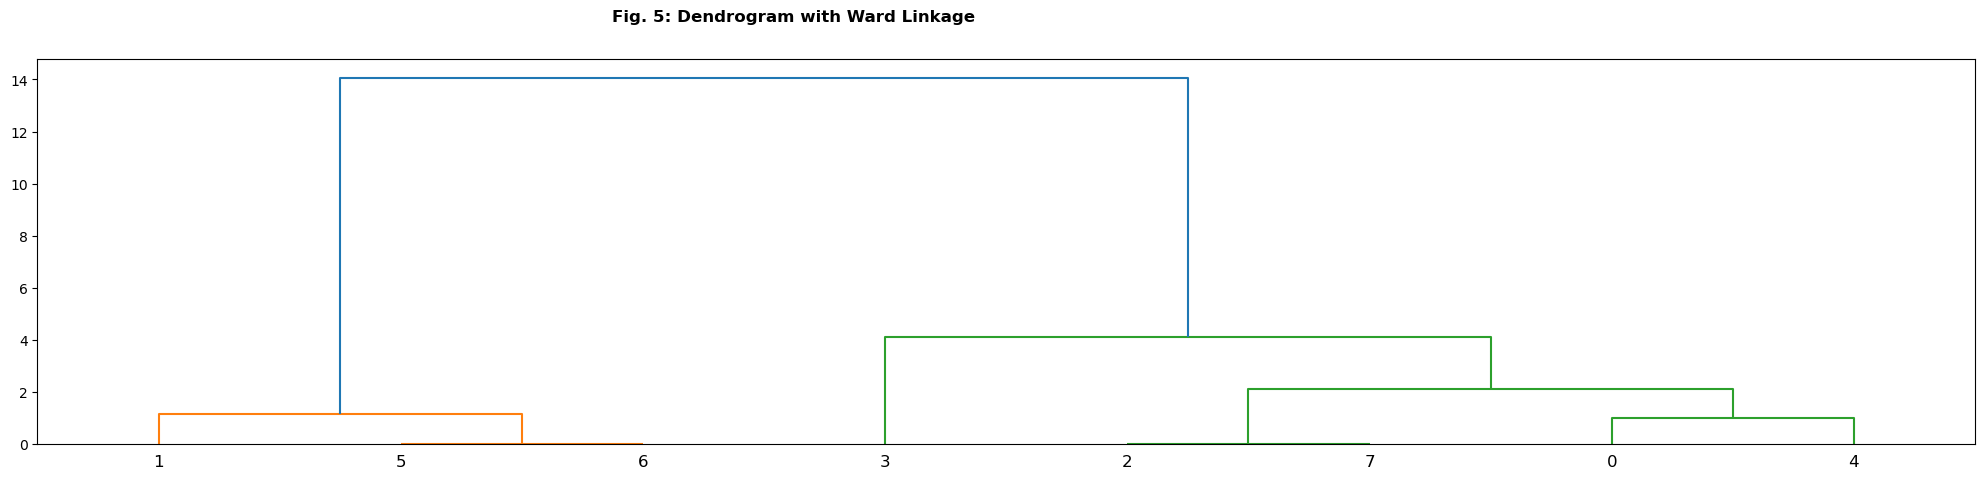

In [6]:
Z = linkage(X, "ward")
fig = plt.figure(figsize=(25, 5))
plt.suptitle(
    "Fig. 5: Dendrogram with Ward Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)

The diagrams we have seen above are called Dendrograms and we chose the number of clusters in hierarchical clustering with the help of a dendrogram.


### **2.4 Dendrogram**

A dendrogram is a diagram that shows the hierarchical relationship between clusters. It shows how clusters are formed at each step. 

Once we have drawn the dendrogram, we slice it horizontally at the desired level then the branches that appear below the cut form individual clusters and its associated membership. Below is an example of a dendrogram with horizontal slices at different levels. 


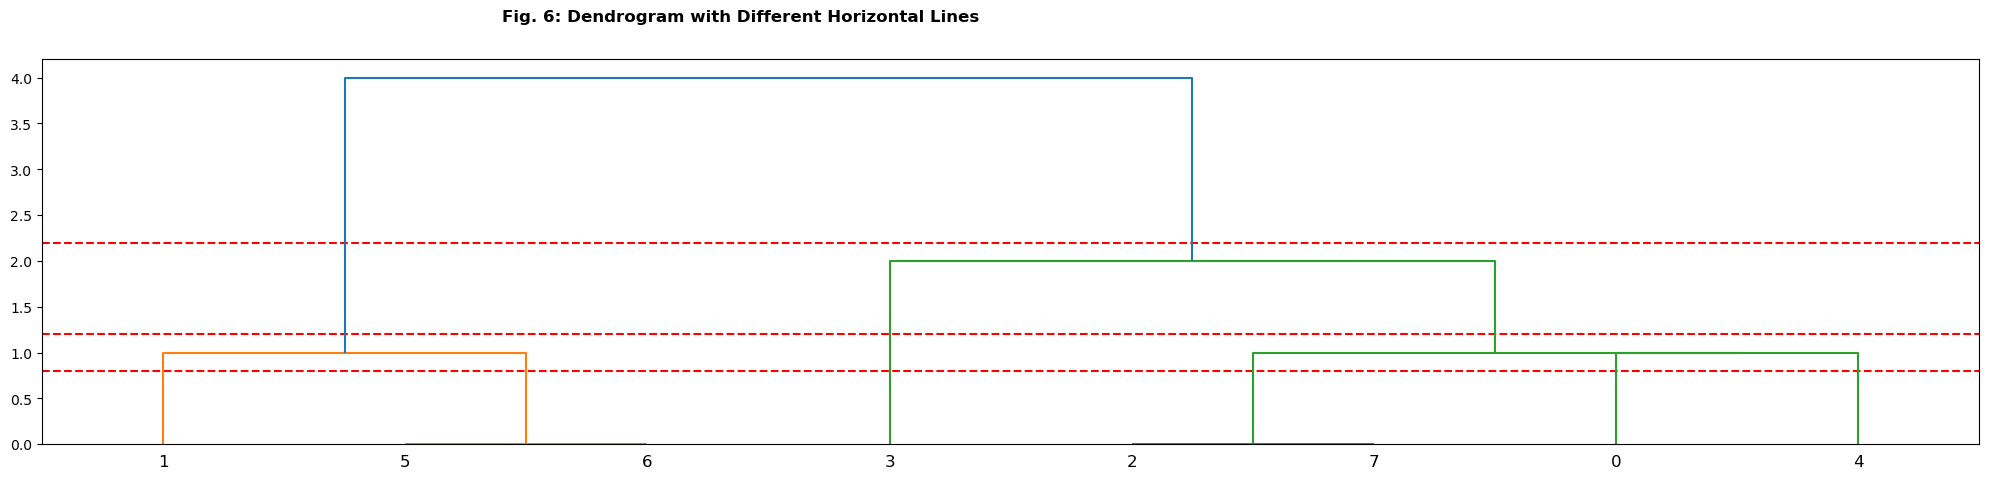

In [7]:
Z = linkage(X)
fig = plt.figure(figsize=(25, 5))
plt.axhline(1.2, color="red", linestyle="--")
plt.axhline(2.2, color="red", linestyle="--")
plt.axhline(0.8, color="red", linestyle="--")
plt.suptitle(
    "Fig. 6: Dendrogram with Different Horizontal Lines",
    fontweight="bold",
    horizontalalignment="right",
)
dn = dendrogram(Z)

## **3. Divisive Hierarchical Clustering**

Divisive hierarchical clustering works in the opposite of agglomerative hierarchical clustering; that is, we start with a single cluster containing all the data points. Then, at each iteration, we split the data into smaller clusters until we have each data point in its own cluster. 

## **4. Implementation of Hierarchical Clustering**

In this demonstration, we use a matrix of daily returns of foreign exchange rates and perform hierarchical clustering to determine if the currencies form clusters that are related to their geographical categories.

### **4.1 Data Scraping**

We start by installing the Yahoo finance API that will be used to download the forex data. We also import libraries for data manipulation and modeling.

In [8]:
# For data manipulation
# For visualization
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# To fetch financial data
import yfinance as yf

plt.style.use("seaborn-darkgrid")
%matplotlib inline

from scipy.cluster.hierarchy import cophenet, dendrogram, linkage

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering

sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to compute distances
from scipy.spatial.distance import pdist

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

/tmp/ipykernel_537/1383997564.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-darkgrid")


We now download the foreign exchange rates rendered to one U.S. dollar.

In [9]:
# Set the ticker as 'EURUSD=X'
forex_data = yf.download("USDEUR=X", start="2019-01-02", end="2022-06-30")
forex_data = forex_data.reset_index()
euro_df = forex_data[["Date", "Adj Close"]]
euro_df.rename(columns={"Adj Close": "euro"}, inplace=True)
# Set the index to a datetime object

forex_data1 = yf.download("USDRUB=X", start="2019-01-02", end="2022-06-30")
forex_data1 = forex_data1.reset_index()
rub_df = forex_data1[["Date", "Adj Close"]]
rub_df.rename(columns={"Adj Close": "rub"}, inplace=True)

forex_data2 = yf.download("USDGBP=X", start="2019-01-02", end="2022-06-30")
forex_data2 = forex_data2.reset_index()
gbp_df = forex_data2[["Date", "Adj Close"]]
gbp_df.rename(columns={"Adj Close": "gbp"}, inplace=True)

forex_data3 = yf.download("USDJPY=X", start="2019-01-02", end="2022-06-30")
forex_data3 = forex_data3.reset_index()
jpy_df = forex_data3[["Date", "Adj Close"]]
jpy_df.rename(columns={"Adj Close": "jpy"}, inplace=True)

forex_data4 = yf.download("USDKES=X", start="2019-01-02", end="2022-06-30")
forex_data4 = forex_data4.reset_index()
kes_df = forex_data4[["Date", "Adj Close"]]
kes_df.rename(columns={"Adj Close": "kes"}, inplace=True)

forex_data5 = yf.download("USDCNY=X", start="2019-01-02", end="2022-06-30")
forex_data5 = forex_data5.reset_index()
cny_df = forex_data5[["Date", "Adj Close"]]
cny_df.rename(columns={"Adj Close": "cny"}, inplace=True)

forex_data6 = yf.download("USDKRW=X", start="2019-01-02", end="2022-06-30")
forex_data6 = forex_data6.reset_index()
krw_df = forex_data6[["Date", "Adj Close"]]
krw_df.rename(columns={"Adj Close": "krw"}, inplace=True)

forex_data7 = yf.download("USDSGD=X", start="2019-01-02", end="2022-06-30")
forex_data7 = forex_data7.reset_index()
sgd_df = forex_data7[["Date", "Adj Close"]]
sgd_df.rename(columns={"Adj Close": "sgd"}, inplace=True)

forex_data8 = yf.download("USDTWD=X", start="2019-01-02", end="2022-06-30")
forex_data8 = forex_data8.reset_index()
twd_df = forex_data8[["Date", "Adj Close"]]
twd_df.rename(columns={"Adj Close": "twd"}, inplace=True)

forex_data9 = yf.download("USDNGN=X", start="2019-01-02", end="2022-06-30")
forex_data9 = forex_data9.reset_index()
ngn_df = forex_data9[["Date", "Adj Close"]]
ngn_df.rename(columns={"Adj Close": "ngn"}, inplace=True)

forex_data10 = yf.download("USDZAR=X", start="2019-01-02", end="2022-06-30")
forex_data10 = forex_data10.reset_index()
zar_df = forex_data10[["Date", "Adj Close"]]
zar_df.rename(columns={"Adj Close": "zar"}, inplace=True)

forex_data11 = yf.download("USDMYR=X", start="2019-01-02", end="2022-06-30")
forex_data11 = forex_data11.reset_index()
myr_df = forex_data11[["Date", "Adj Close"]]
myr_df.rename(columns={"Adj Close": "myr"}, inplace=True)

forex_data12 = yf.download("USDIDR=X", start="2019-01-02", end="2022-06-30")
forex_data12 = forex_data12.reset_index()
idr_df = forex_data12[["Date", "Adj Close"]]
idr_df.rename(columns={"Adj Close": "idr"}, inplace=True)

forex_data13 = yf.download("USDTHB=X", start="2019-01-02", end="2022-06-30")
forex_data13 = forex_data13.reset_index()
thb_df = forex_data13[["Date", "Adj Close"]]
thb_df.rename(columns={"Adj Close": "thb"}, inplace=True)

forex_data14 = yf.download("USDAUD=X", start="2019-01-02", end="2022-06-30")
forex_data14 = forex_data14.reset_index()
aud_df = forex_data14[["Date", "Adj Close"]]
aud_df.rename(columns={"Adj Close": "aud"}, inplace=True)

forex_data15 = yf.download("USDNZD=X", start="2019-01-02", end="2022-06-30")
forex_data15 = forex_data15.reset_index()
nzd_df = forex_data15[["Date", "Adj Close"]]
nzd_df.rename(columns={"Adj Close": "nzd"}, inplace=True)

forex_data16 = yf.download("USDCAD=X", start="2019-01-02", end="2022-06-30")
forex_data16 = forex_data16.reset_index()
cad_df = forex_data16[["Date", "Adj Close"]]
cad_df.rename(columns={"Adj Close": "cad"}, inplace=True)

forex_data17 = yf.download("USDCHF=X", start="2019-01-02", end="2022-06-30")
forex_data17 = forex_data17.reset_index()
chf_df = forex_data17[["Date", "Adj Close"]]
chf_df.rename(columns={"Adj Close": "chf"}, inplace=True)

forex_data18 = yf.download("USDNOK=X", start="2019-01-02", end="2022-06-30")
forex_data18 = forex_data18.reset_index()
nok_df = forex_data18[["Date", "Adj Close"]]
nok_df.rename(columns={"Adj Close": "nok"}, inplace=True)

forex_data19 = yf.download("USDAUD=X", start="2019-01-02", end="2022-06-30")
forex_data19 = forex_data19.reset_index()
sek_df = forex_data19[["Date", "Adj Close"]]
sek_df.rename(columns={"Adj Close": "sek"}, inplace=True)

forex_data20 = yf.download("USDARS=X", start="2019-01-02", end="2022-06-30")
forex_data20 = forex_data20.reset_index()
ars_df = forex_data20[["Date", "Adj Close"]]
ars_df.rename(columns={"Adj Close": "ars"}, inplace=True)

forex_data21 = yf.download("USDPLN=X", start="2019-01-02", end="2022-06-30")
forex_data21 = forex_data21.reset_index()
pln_df = forex_data21[["Date", "Adj Close"]]
pln_df.rename(columns={"Adj Close": "pln"}, inplace=True)

forex_data22 = yf.download("USDPHP=X", start="2019-01-02", end="2022-06-30")
forex_data22 = forex_data22.reset_index()
php_df = forex_data22[["Date", "Adj Close"]]
php_df.rename(columns={"Adj Close": "php"}, inplace=True)

forex_data23 = yf.download("USDRON=X", start="2019-01-02", end="2022-06-30")
forex_data23 = forex_data23.reset_index()
ron_df = forex_data23[["Date", "Adj Close"]]
ron_df.rename(columns={"Adj Close": "ron"}, inplace=True)

forex_data24 = yf.download("USDHUF=X", start="2019-01-02", end="2022-06-30")
forex_data24 = forex_data24.reset_index()
huf_df = forex_data24[["Date", "Adj Close"]]
huf_df.rename(columns={"Adj Close": "huf"}, inplace=True)

forex_data25 = yf.download("USDBRL=X", start="2019-01-02", end="2022-06-30")
forex_data25 = forex_data25.reset_index()
brl_df = forex_data25[["Date", "Adj Close"]]
brl_df.rename(columns={"Adj Close": "brl"}, inplace=True)

forex_data26 = yf.download("USDCLP=X", start="2019-01-02", end="2022-06-30")
forex_data26 = forex_data26.reset_index()
clp_df = forex_data26[["Date", "Adj Close"]]
clp_df.rename(columns={"Adj Close": "clp"}, inplace=True)

forex_data27 = yf.download("USDMXN=X", start="2019-01-02", end="2022-06-30")
forex_data27 = forex_data27.reset_index()
mxn_df = forex_data27[["Date", "Adj Close"]]
mxn_df.rename(columns={"Adj Close": "mxn"}, inplace=True)

forex_data28 = yf.download("USDCOP=X", start="2019-01-02", end="2022-06-30")
forex_data28 = forex_data28.reset_index()
cop_df = forex_data28[["Date", "Adj Close"]]
cop_df.rename(columns={"Adj Close": "cop"}, inplace=True)

forex_data29 = yf.download("USDILS=X", start="2019-01-02", end="2022-06-30")
forex_data29 = forex_data29.reset_index()
ils_df = forex_data29[["Date", "Adj Close"]]
ils_df.rename(columns={"Adj Close": "ils"}, inplace=True)

forex_data30 = yf.download("USDTRY=X", start="2019-01-02", end="2022-06-30")
forex_data30 = forex_data30.reset_index()
try_df = forex_data30[["Date", "Adj Close"]]
try_df.rename(columns={"Adj Close": "try"}, inplace=True)

forex_data31 = yf.download("USDINR=X", start="2019-01-02", end="2022-06-30")
forex_data31 = forex_data31.reset_index()
inr_df = forex_data31[["Date", "Adj Close"]]
inr_df.rename(columns={"Adj Close": "inr"}, inplace=True)

[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_537/2991467607.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  euro_df.rename(columns={"Adj Close": "euro"}, inplace=True)


[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_537/2991467607.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rub_df.rename(columns={"Adj Close": "rub"}, inplace=True)


[*********************100%***********************]  1 of 1 completed


...

/tmp/ipykernel_537/2991467607.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ils_df.rename(columns={"Adj Close": "ils"}, inplace=True)


[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_537/2991467607.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  try_df.rename(columns={"Adj Close": "try"}, inplace=True)


[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_537/2991467607.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inr_df.rename(columns={"Adj Close": "inr"}, inplace=True)


The currencies are combined into one dataframe that will form the basis of our modeling.

In [10]:
from functools import reduce

df_currencies = reduce(
    lambda x, y: pd.merge(x, y, on="Date", how="outer"),
    [
        kes_df,
        ars_df,
        php_df,
        myr_df,
        ils_df,
        cop_df,
        euro_df,
        ngn_df,
        huf_df,
        ron_df,
        cny_df,
        rub_df,
        clp_df,
        sgd_df,
        twd_df,
        krw_df,
        idr_df,
        thb_df,
        inr_df,
        pln_df,
        try_df,
        brl_df,
        mxn_df,
        zar_df,
        gbp_df,
        jpy_df,
        aud_df,
        nzd_df,
        cad_df,
        chf_df,
        nok_df,
        sek_df,
    ],
)
df_currencies.set_index("Date", inplace=True)

df_currencies.head(10)

,kes,ars,php,myr,ils,cop,euro,ngn,huf,ron,cny,rub,clp,sgd,twd,krw,idr,thb,inr,pln,try,brl,mxn,zar,gbp,jpy,aud,nzd,cad,chf,nok,sek
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-02,100.839996,37.584999,52.470001,4.1295,3.73567,3245.000000,0.87247,362.109985,280.070007,4.0535,6.8775,68.892502,693.500000,1.36240,30.500999,1113.800049,14460.000000,32.333000,69.709999,3.74010,5.28870,3.8799,19.628300,14.38765,0.78405,109.667999,1.41886,1.48951,1.36254,0.98200,8.64645,1.41886
2019-01-03,100.430000,37.764000,52.549999,4.1350,3.74285,3235.000000,0.88354,364.000000,284.700012,4.1140,6.8611,69.025803,696.299988,1.36710,30.759001,1122.180054,14409.700195,32.270000,69.959999,3.79770,5.51530,3.7863,19.607700,14.55830,0.79860,107.441002,1.44530,1.50748,1.36312,0.98870,8.77981,1.44530
2019-01-04,100.449997,37.445999,52.570000,4.1400,3.72550,3243.000000,0.87788,363.500000,281.528015,4.0887,6.8711,68.859100,693.299988,1.36410,30.863001,1124.119995,14375.400391,32.175999,70.300003,3.76560,5.47220,3.7551,19.604500,14.30900,0.79184,107.807999,1.42730,1.49510,1.34788,0.98710,8.69065,1.42730
2019-01-07,101.050003,37.304001,52.380001,4.1220,3.71048,3191.000000,0.87639,364.000000,281.170013,4.0811,6.8684,67.566002,680.700012,1.35840,30.783001,1114.400024,14267.000000,31.930000,69.525002,3.76038,5.32700,3.6612,19.381901,13.98070,0.78524,108.522003,1.40375,1.48291,1.33693,0.98576,8.60577,1.40375
2019-01-08,100.110001,37.298000,52.294998,4.1123,3.70635,3179.000000,0.87110,364.000000,279.632996,4.0570,6.8500,66.748299,681.000000,1.35520,30.802999,1116.400024,14083.000000,31.927000,69.809998,3.74111,5.38380,3.7341,19.364620,13.86070,0.78210,108.615997,1.39940,1.48067,1.32960,0.97910,8.52646,1.39940
2019-01-09,100.839996,37.536999,52.500000,4.1143,3.69700,3160.300049,0.87290,363.000000,280.739990,4.0709,6.8522,66.886497,679.900024,1.35710,30.816000,1121.050049,14138.000000,32.012001,70.330002,3.75000,5.48250,3.7124,19.327900,13.94630,0.78506,108.776001,1.39600,1.48357,1.32470,0.98077,8.53240,1.39600
2019-01-10,100.849998,37.356998,52.209000,4.1015,3.67380,3132.500000,0.86543,364.880005,277.799988,4.0392,6.8156,66.652702,675.500000,1.35260,30.711000,1118.670044,14130.000000,31.888000,70.550499,3.72290,5.47560,3.6800,19.205900,13.84390,0.78127,108.189003,1.39360,1.47252,1.32115,0.97395,8.45935,1.39360
2019-01-11,100.809998,37.355999,52.113998,4.0950,3.66683,3135.000000,0.86880,364.500000,278.875000,4.0613,6.7875,66.867203,675.599976,1.35140,30.778999,1116.550049,14048.000000,31.910000,70.720001,3.73223,5.42442,3.7079,19.130751,13.85456,0.78407,108.297997,1.39140,1.47380,1.32390,0.98401,8.47260,1.39140
2019-01-14,100.760002,36.929001,52.169998,4.0935,3.67150,3145.199951,0.87259,364.500000,280.027008,4.0756,6.7620,66.852203,674.400024,1.35331,30.785999,1118.599976,14038.000000,31.931000,70.370003,3.74326,5.48080,3.6596,19.138901,13.85670,0.77822,108.458000,1.38790,1.46590,1.32674,0.98370,8.53830,1.38790


We have 911 rows of daily rates and 32 currencies in our dataframe.

In [11]:
df_currencies.shape

(910, 32)

In [12]:
df_currencies.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 910 entries, 2019-01-02 to 2022-06-29
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kes     910 non-null    float64
 1   ars     910 non-null    float64
 2   php     910 non-null    float64
 3   myr     909 non-null    float64
 4   ils     909 non-null    float64
 5   cop     910 non-null    float64
 6   euro    910 non-null    float64
 7   ngn     910 non-null    float64
 8   huf     910 non-null    float64
 9   ron     910 non-null    float64
 10  cny     909 non-null    float64
 11  rub     910 non-null    float64
 12  clp     910 non-null    float64
 13  sgd     910 non-null    float64
 14  twd     910 non-null    float64
 15  krw     910 non-null    float64
 16  idr     910 non-null    float64
 17  thb     910 non-null    float64
 18  inr     910 non-null    float64
 19  pln     910 non-null    float64
 20  try     910 non-null    float64
 21  brl     910 non-null

In [13]:
df_currencies.describe()

,kes,ars,php,myr,ils,cop,euro,ngn,huf,ron,cny,rub,clp,sgd,twd,krw,idr,thb,inr,pln,try,brl,mxn,zar,gbp,jpy,aud,nzd,cad,chf,nok,sek
count,910.000000,910.000000,910.000000,909.000000,909.000000,910.000000,910.000000,910.000000,910.000000,910.000000,909.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000
mean,106.271934,77.051689,50.485349,4.175382,3.389244,3617.320032,0.877961,383.293233,306.353554,4.253118,6.713804,71.452912,761.757275,1.362522,29.281230,1171.949242,14347.385474,31.742338,73.359169,3.916159,8.266750,4.864419,20.328788,15.240861,0.764365,110.552330,1.405214,1.493344,1.302014,0.948027,8.953511,1.405214
std,4.893143,23.725583,1.559282,0.087830,0.157674,278.697328,0.033852,22.832106,20.648835,0.163693,0.263543,8.933727,57.698667,0.023969,1.256438,44.064748,404.634164,1.264013,2.290538,0.188429,3.120143,0.669541,1.305374,1.155624,0.032379,6.212416,0.075673,0.074478,0.045776,0.037266,0.509764,0.075673
min,98.289001,36.929001,47.556763,4.004000,3.075430,3038.899902,0.810300,305.910004,274.089996,3.942800,6.308400,53.090000,647.599976,1.317210,27.423700,1083.680054,13213.240234,29.680000,68.367599,3.615330,5.180200,3.642800,18.542999,13.248800,0.702900,102.678001,1.253600,1.343130,1.203800,0.878070,7.649780,1.253600
25%,101.525351,59.644659,48.834499,4.120000,3.248600,3393.562500,0.847293,360.500000,294.328499,4.136750,6.465000,65.080400,714.999985,1.347850,27.963474,1133.102448,14121.199951,30.780001,71.423975,3.789040,5.891652,4.127475,19.364770,14.435825,0.736488,107.198999,1.357205,1.433493,1.265857,0.916613,8.589165,1.357205
50%,106.849998,76.137150,50.683500,4.163000,3.405050,3666.599976,0.883890,380.000000,301.547012,4.243000,6.711300,72.728699,769.350006,1.358005,29.330750,1177.005005,14287.196289,31.430000,73.675648,3.859150,7.352600,5.139461,20.024710,14.924550,0.764695,109.124500,1.399521,1.491780,1.307485,0.940440,8.849730,1.399521
75%,109.375002,97.062557,51.814502,4.208500,3.516800,3834.137512,0.901707,410.364998,312.455002,4.337025,6.971900,74.637774,805.357483,1.374180,30.437999,1198.150024,14486.501709,32.723501,74.988373,3.976632,8.614825,5.402748,20.711285,15.789650,0.788078,111.353252,1.448519,1.538960,1.330150,0.983745,9.158745,1.448519
max,116.820000,124.855911,54.890999,4.440000,3.836750,4174.750000,0.963430,419.000000,384.059998,4.766700,7.178000,138.965103,920.090027,1.456300,31.694000,1299.810059,16504.800781,35.484001,79.073196,4.583200,17.346001,5.886400,25.336201,19.248600,0.869990,136.268997,1.741280,1.777430,1.449820,1.020300,11.759900,1.741280


The next step is to find missing values in our dataset.

In [14]:
df_currencies.isna().sum()

kes     0
ars     0
php     0
myr     1
ils     1
cop     0
euro    0
ngn     0
huf     0
ron     0
cny     1
rub     0
clp     0
sgd     0
twd     0
krw     0
idr     0
thb     0
inr     0
pln     0
try     0
brl     0
mxn     0
zar     0
gbp     0
jpy     0
aud     0
nzd     0
cad     0
chf     0
nok     0
sek     0
dtype: int64

We impute the missing value by propagating the observations from the last day to the missing day data.

In [15]:
df_currencies.fillna(method="ffill", inplace=True)
df_currencies.isna().sum()

kes     0
ars     0
php     0
myr     0
ils     0
cop     0
euro    0
ngn     0
huf     0
ron     0
cny     0
rub     0
clp     0
sgd     0
twd     0
krw     0
idr     0
thb     0
inr     0
pln     0
try     0
brl     0
mxn     0
zar     0
gbp     0
jpy     0
aud     0
nzd     0
cad     0
chf     0
nok     0
sek     0
dtype: int64

Since the currencies differ a lot in value range, we scale them to ensure they have the same mean and unit variance.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [16]:
# Scaling the data to bring it to the same scale

sc = StandardScaler()
subset_scaled_df = pd.DataFrame(
    sc.fit_transform(df_currencies),
    columns=df_currencies.columns,
)
subset_scaled_df.head()

,kes,ars,php,myr,ils,cop,euro,ngn,huf,ron,cny,rub,clp,sgd,twd,krw,idr,thb,inr,pln,try,brl,mxn,zar,gbp,jpy,aud,nzd,cad,chf,nok,sek
0,-1.110723,-1.664380,1.273499,-0.522395,2.193892,-1.336664,-0.162309,-0.928294,-1.273583,-1.220130,0.620241,-0.286758,-1.183646,-0.005082,0.971350,-1.320356,0.278465,0.467548,-1.594026,-0.934869,-0.954984,-1.471247,-0.536914,-0.738718,0.608286,-0.142427,0.180433,-0.051500,1.322929,0.912135,-0.602691,0.180433
1,-1.194559,-1.656832,1.324832,-0.459709,2.239402,-1.372565,0.164883,-0.845469,-1.049234,-0.850335,0.557984,-0.271829,-1.135092,0.191107,1.176807,-1.130077,0.154087,0.417680,-1.484821,-0.629015,-0.882320,-1.611121,-0.552703,-0.590968,1.057896,-0.501100,0.530023,0.189913,1.335605,1.092024,-0.340936,0.530023
2,-1.190470,-1.670242,1.337666,-0.402729,2.129430,-1.343845,-0.002408,-0.867380,-1.202934,-1.004978,0.595945,-0.290499,-1.187115,0.065877,1.259626,-1.086028,0.069273,0.343271,-1.336301,-0.799465,-0.896141,-1.657746,-0.555157,-0.806814,0.849006,-0.441992,0.292027,0.023597,1.002500,1.049066,-0.515937,0.292027
3,-1.067780,-1.676230,1.215748,-0.607867,2.034225,-1.530529,-0.046448,-0.845469,-1.220281,-1.051431,0.585696,-0.435322,-1.405610,-0.172056,1.195919,-1.306733,-0.198771,0.148547,-1.674836,-0.827183,-0.942703,-1.798068,-0.725775,-1.091059,0.645059,-0.326997,-0.019352,-0.140166,0.763163,1.013088,-0.682537,-0.019352
4,-1.259992,-1.676484,1.161204,-0.718419,2.008048,-1.573611,-0.202802,-0.845469,-1.294758,-1.198737,0.515845,-0.526902,-1.400408,-0.305630,1.211844,-1.261320,-0.653753,0.146173,-1.550344,-0.929505,-0.924488,-1.689127,-0.739021,-1.194956,0.548031,-0.311859,-0.076867,-0.170260,0.602948,0.834272,-0.838205,-0.076867


In [17]:
# Generate simple percentage returns to calculate the respective betas

df_returns = (df_currencies / df_currencies.shift(-1)) - 1
df_returns.head()

,kes,ars,php,myr,ils,cop,euro,ngn,huf,ron,cny,rub,clp,sgd,twd,krw,idr,thb,inr,pln,try,brl,mxn,zar,gbp,jpy,aud,nzd,cad,chf,nok,sek
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-02,0.004082,-0.004740,-0.001522,-0.001330,-0.001918,0.003091,-0.012529,-0.005192,-0.016263,-0.014706,0.002390,-0.001931,-0.004021,-0.003438,-0.008388,-0.007468,0.003491,0.001952,-0.003573,-0.015167,-0.041086,0.024721,0.001051,-0.011722,-0.018219,0.020728,-0.018294,-0.011921,-0.000425,-0.006777,-0.015189,-0.018294
2019-01-03,-0.000199,0.008492,-0.000380,-0.001208,0.004657,-0.002467,0.006447,0.001376,0.011267,0.006188,-0.001455,0.002421,0.004327,0.002199,-0.003370,-0.001726,0.002386,0.002921,-0.004836,0.008525,0.007876,0.008309,0.000163,0.017423,0.008537,-0.003404,0.012611,0.008280,0.011307,0.001621,0.010259,0.012611
2019-01-04,-0.005938,0.003807,0.003627,0.004367,0.004048,0.016296,0.001700,-0.001374,0.001273,0.001862,0.000393,0.019138,0.018510,0.004196,0.002599,0.008722,0.007598,0.007704,0.011147,0.001388,0.027257,0.025647,0.011485,0.023482,0.008405,-0.006579,0.016777,0.008220,0.008190,0.001359,0.009863,0.016777
2019-01-07,0.009390,0.000161,0.001625,0.002359,0.001114,0.003775,0.006073,0.000000,0.005497,0.005940,0.002686,0.012251,-0.000441,0.002361,-0.000649,-0.001791,0.013065,0.000094,-0.004082,0.005151,-0.010550,-0.019523,0.000892,0.008658,0.004015,-0.000865,0.003108,0.001513,0.005513,0.006802,0.009302,0.003108
2019-01-08,-0.007239,-0.006367,-0.003905,-0.000486,0.002529,0.005917,-0.002062,0.002755,-0.003943,-0.003414,-0.000321,-0.002066,0.001618,-0.001400,-0.000422,-0.004148,-0.003890,-0.002655,-0.007394,-0.002371,-0.018003,0.005845,0.001900,-0.006138,-0.003770,-0.001471,0.002436,-0.001955,0.003699,-0.001703,-0.000696,0.002436


### **4.2 Model Training**


In [18]:
subset_scaled_df.drop(subset_scaled_df.tail(1).index, inplace=True)

In [19]:
subset_scaled_df.tail()

,kes,ars,php,myr,ils,cop,euro,ngn,huf,ron,cny,rub,clp,sgd,twd,krw,idr,thb,inr,pln,try,brl,mxn,zar,gbp,jpy,aud,nzd,cad,chf,nok,sek
904,2.111882,1.966231,2.518345,2.514849,0.370437,1.306543,2.112377,1.378500,3.297225,2.680155,-0.097624,-1.972592,1.937725,0.959590,0.352596,2.716832,1.197578,2.804251,2.086130,2.577192,2.911483,0.386119,-0.147004,0.583295,1.571469,4.141836,0.412479,1.202169,-0.192877,0.483085,1.749592,0.412479
905,2.122107,1.974181,2.511930,2.594626,0.292664,1.433992,2.028732,1.373681,3.302799,2.595194,-0.049411,-1.846595,2.219689,1.026798,0.310946,2.854889,1.225520,2.855702,2.111551,2.805468,2.910392,0.491922,-0.214071,0.570351,1.603915,4.102378,0.568102,1.360842,-0.123151,0.368438,1.879626,0.568102
906,2.132330,1.983559,2.685179,2.606022,0.385839,1.656003,2.145776,1.371489,3.547498,2.716829,-0.063837,-1.902594,2.458475,1.111954,0.264281,2.903253,1.222552,2.961774,2.089406,2.921225,2.911451,0.558272,-0.244424,0.601347,1.583520,3.911686,0.572862,1.309120,-0.072225,0.357967,2.004693,0.572862
907,2.142555,1.984951,2.826990,2.554738,0.135343,1.871983,2.023412,1.367106,3.515275,2.572577,-0.096105,-2.025790,2.698473,0.960008,0.328705,2.641676,1.220574,2.934861,2.137409,2.744936,2.694354,0.563352,-0.334363,0.453718,1.539023,3.947441,0.462855,1.214004,-0.268940,0.248691,1.738011,0.462855
908,2.152779,2.007486,2.807099,2.577535,0.191121,1.844447,1.984397,1.367545,3.587958,2.531627,-0.088891,-2.056590,2.745641,0.953330,0.118472,2.594217,1.096938,2.862828,2.219883,2.695020,2.660652,0.556479,-0.326437,0.507744,1.569924,4.007515,0.520239,1.282252,-0.330359,0.218352,1.646665,0.520239


We now find the **cophenetic correlation** using a combination of distance metrics and linkage methods. A cophenetic correlation measures the dendrogram's ability to preserve the initial unmodeled data points. The higher the cophenetic correlation, the better the performance of a dendogram in preserving the original distance. 

The cophenetic correlation is defined as:
$$c = \frac{\sum_{i<j} (Y_{ij} - y)(Z_{ij} - z)}{\sum_{i<j}{(Y_{ij} - y)\sum_{i<j}(Z_{ij} - z)}}$$

where

- $Y_{ij}$ is the distance between $i$ and $j$ in $Y$.
- $Z_{ij}$ is the cophenetic distance between $i$ and $j$.
- $y$ and $z$ are the mean of $Y$ and $Z$ respectively.

In [20]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df.T, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df.T))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.4514542027603476
Cophenetic correlation for Euclidean distance and complete linkage is 0.6603754108840691
Cophenetic correlation for Euclidean distance and average linkage is 0.7068314554168657
Cophenetic correlation for Euclidean distance and weighted linkage is 0.730119008220271
Cophenetic correlation for Chebyshev distance and single linkage is 0.1974737788849682
Cophenetic correlation for Chebyshev distance and complete linkage is 0.4593880400987013
Cophenetic correlation for Chebyshev distance and average linkage is 0.36672824744493543
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.3142745892307674
Cophenetic correlation for Cityblock distance and single linkage is 0.4822957833911452
Cophenetic correlation for Cityblock distance and complete linkage is 0.7352727905521788
Cophenetic correlation for Cityblock distance and average linkage is 0.690302094643408
Cophenetic correlation for City

We now identify the distance metric and linkage method that give the highest cophenetic correlation.

In [21]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7352727905521788, which is obtained with Cityblock distance and complete linkage


Since the Euclidean distance gives us the best performance, we combine it with different linkage methods and evaluate which combination will improve our performance.

In [22]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df.T, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df.T))
    print("Cophenetic correlation for {} linkage is {}".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.4514542027603476
Cophenetic correlation for complete linkage is 0.6603754108840691
Cophenetic correlation for average linkage is 0.7068314554168657
Cophenetic correlation for centroid linkage is 0.7447300507332353
Cophenetic correlation for ward linkage is 0.7089770637974209
Cophenetic correlation for weighted linkage is 0.730119008220271


Again, we print the linkage method that gives the highest cophenetic correlation.

In [23]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7447300507332353, which is obtained with centroid linkage


Let us plot the graphs of different dendrograms to visualize how clusters vary with different linkage methods.

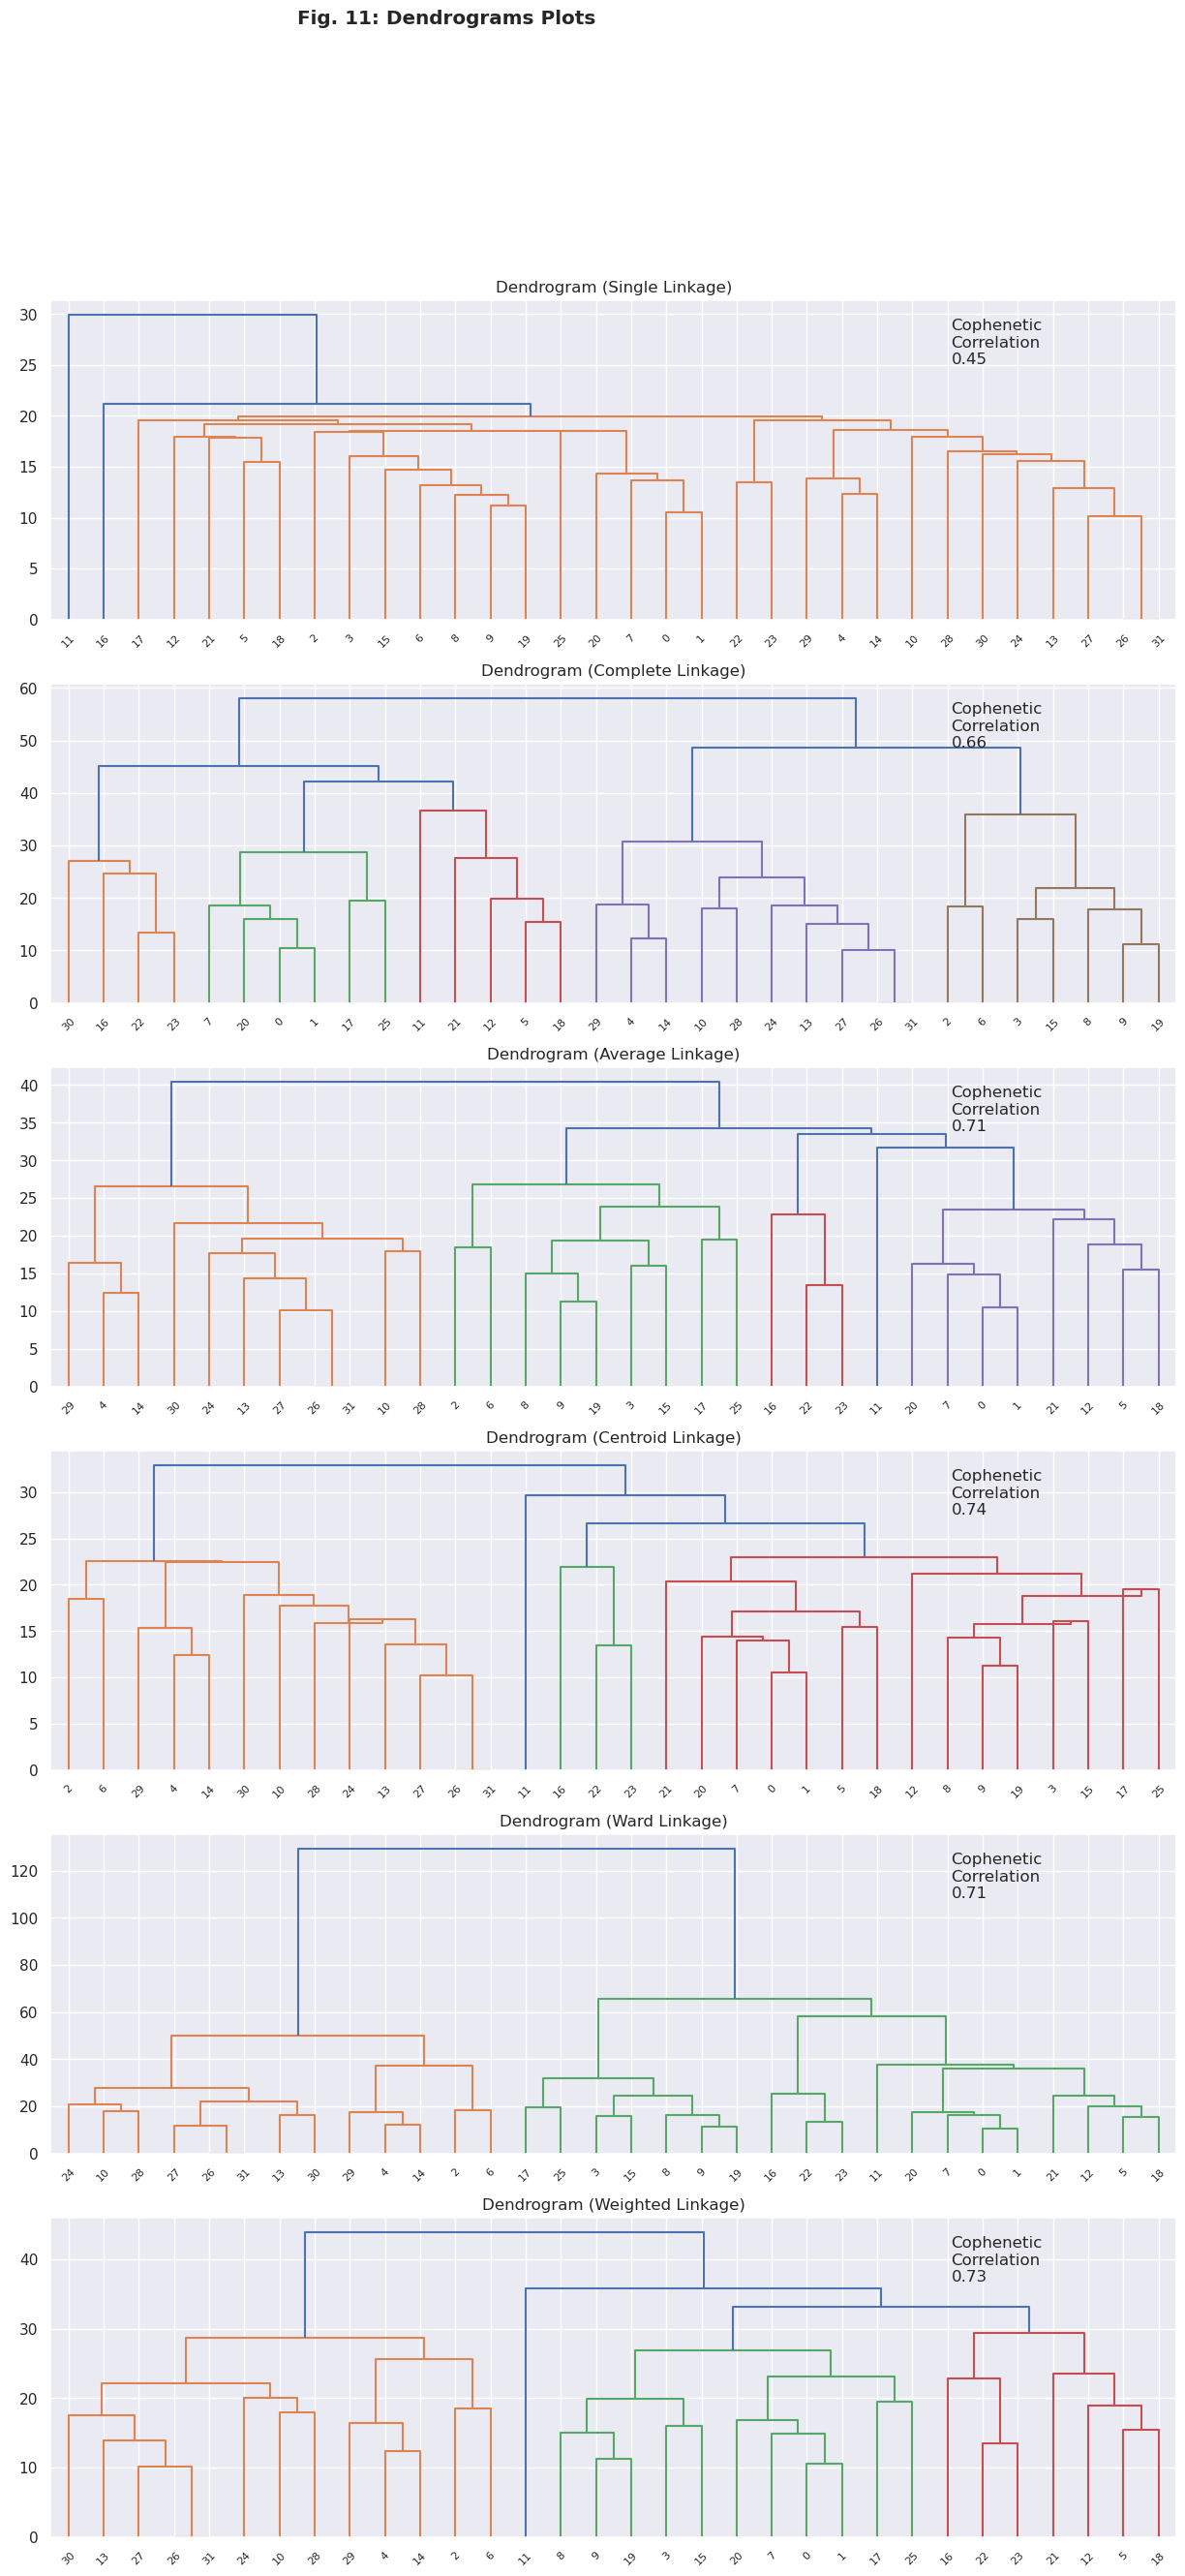

In [24]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))
# `plt.suptitle`()

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df.T, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")
    fig.suptitle(
        "Fig. 11: Dendrograms Plots", fontweight="bold", horizontalalignment="right"
    )

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df.T))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

To find the components of each cluster, we can train the data as shown below, then find the components as demonstrated in the steps below.

In [25]:
HCmodel = AgglomerativeClustering(n_clusters=3, affinity="euclidean", linkage="average")
HCmodel.fit(subset_scaled_df.T)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


AgglomerativeClustering(affinity='euclidean', linkage='average', n_clusters=3)

In [26]:
df_currencies_t = df_currencies.T
subset_scaled_df_t = subset_scaled_df.T

subset_scaled_df_t["HC_Clusters"] = HCmodel.labels_
df_currencies_t["HC_Clusters"] = HCmodel.labels_

In [27]:
cluster_profile = df_currencies_t.groupby("HC_Clusters").mean()

In [28]:
cluster_profile.head()

Date,2019-01-02 00:00:00,2019-01-03 00:00:00,2019-01-04 00:00:00,2019-01-07 00:00:00,2019-01-08 00:00:00,2019-01-09 00:00:00,2019-01-10 00:00:00,2019-01-11 00:00:00,2019-01-14 00:00:00,2019-01-15 00:00:00,2019-01-16 00:00:00,2019-01-17 00:00:00,2019-01-18 00:00:00,2019-01-21 00:00:00,2019-01-22 00:00:00,2019-01-23 00:00:00,2019-01-24 00:00:00,2019-01-25 00:00:00,2019-01-28 00:00:00,2019-01-29 00:00:00,2019-01-30 00:00:00,2019-01-31 00:00:00,2019-02-01 00:00:00,2019-02-04 00:00:00,2019-02-05 00:00:00,2019-02-06 00:00:00,2019-02-07 00:00:00,2019-02-08 00:00:00,2019-02-11 00:00:00,2019-02-12 00:00:00,2019-02-13 00:00:00,2019-02-14 00:00:00,2019-02-15 00:00:00,2019-02-18 00:00:00,2019-02-19 00:00:00,2019-02-20 00:00:00,2019-02-21 00:00:00,2019-02-22 00:00:00,2019-02-25 00:00:00,2019-02-26 00:00:00,2019-02-27 00:00:00,2019-02-28 00:00:00,2019-03-01 00:00:00,2019-03-04 00:00:00,2019-03-05 00:00:00,2019-03-06 00:00:00,2019-03-07 00:00:00,2019-03-08 00:00:00,2019-03-11 00:00:00,2019-03-12 00:00:00,2019-03-13 00:00:00,2019-03-14 00:00:00,2019-03-15 00:00:00,2019-03-18 00:00:00,2019-03-19 00:00:00,2019-03-20 00:00:00,2019-03-21 00:00:00,2019-03-22 00:00:00,2019-03-25 00:00:00,2019-03-26 00:00:00,2019-03-27 00:00:00,2019-03-28 00:00:00,2019-03-29 00:00:00,2019-04-01 00:00:00,2019-04-02 00:00:00,2019-04-03 00:00:00,2019-04-04 00:00:00,2019-04-05 00:00:00,2019-04-08 00:00:00,2019-04-09 00:00:00,2019-04-10 00:00:00,2019-04-11 00:00:00,2019-04-12 00:00:00,2019-04-15 00:00:00,2019-04-16 00:00:00,2019-04-17 00:00:00,2019-04-18 00:00:00,2019-04-19 00:00:00,2019-04-22 00:00:00,2019-04-23 00:00:00,2019-04-24 00:00:00,2019-04-25 00:00:00,2019-04-26 00:00:00,2019-04-29 00:00:00,2019-04-30 00:00:00,2019-05-01 00:00:00,2019-05-02 00:00:00,2019-05-03 00:00:00,2019-05-06 00:00:00,2019-05-07 00:00:00,2019-05-08 00:00:00,2019-05-09 00:00:00,2019-05-10 00:00:00,2019-05-13 00:00:00,2019-05-14 00:00:00,2019-05-15 00:00:00,2019-05-16 00:00:00,2019-05-17 00:00:00,2019-05-20 00:00:00,2019-05-21 00:00:00,2019-05-23 00:00:00,2019-05-24 00:00:00,2019-05-27 00:00:00,2019-05-28 00:00:00,2019-05-29 00:00:00,2019-05-30 00:00:00,2019-05-31 00:00:00,2019-06-03 00:00:00,2019-06-04 00:00:00,2019-06-05 00:00:00,2019-06-06 00:00:00,2019-06-07 00:00:00,2019-06-10 00:00:00,2019-06-11 00:00:00,2019-06-12 00:00:00,2019-06-13 00:00:00,2019-06-14 00:00:00,2019-06-17 00:00:00,2019-06-18 00:00:00,2019-06-19 00:00:00,2019-06-20 00:00:00,2019-06-21 00:00:00,2019-06-24 00:00:00,2019-06-25 00:00:00,2019-06-26 00:00:00,2019-06-27 00:00:00,2019-06-28 00:00:00,2019-07-01 00:00:00,2019-07-02 00:00:00,2019-07-03 00:00:00,2019-07-04 00:00:00,2019-07-05 00:00:00,2019-07-08 00:00:00,2019-07-09 00:00:00,2019-07-10 00:00:00,2019-07-11 00:00:00,2019-07-12 00:00:00,2019-07-15 00:00:00,2019-07-16 00:00:00,2019-07-17 00:00:00,2019-07-18 00:00:00,2019-07-19 00:00:00,2019-07-22 00:00:00,2019-07-23 00:00:00,2019-07-24 00:00:00,2019-07-25 00:00:00,2019-07-26 00:00:00,2019-07-29 00:00:00,2019-07-30 00:00:00,2019-07-31 00:00:00,2019-08-01 00:00:00,2019-08-02 00:00:00,2019-08-05 00:00:00,2019-08-06 00:00:00,2019-08-07 00:00:00,2019-08-08 00:00:00,2019-08-09 00:00:00,2019-08-12 00:00:00,2019-08-13 00:00:00,2019-08-14 00:00:00,2019-08-15 00:00:00,2019-08-16 00:00:00,2019-08-19 00:00:00,2019-08-20 00:00:00,2019-08-21 00:00:00,2019-08-22 00:00:00,2019-08-23 00:00:00,2019-08-26 00:00:00,2019-08-27 00:00:00,2019-08-28 00:00:00,2019-08-29 00:00:00,2019-08-30 00:00:00,2019-09-02 00:00:00,2019-09-03 00:00:00,2019-09-04 00:00:00,2019-09-05 00:00:00,2019-09-06 00:00:00,2019-09-09 00:00:00,2019-09-10 00:00:00,2019-09-11 00:00:00,2019-09-12 00:00:00,2019-09-13 00:00:00,2019-09-16 00:00:00,2019-09-17 00:00:00,2019-09-18 00:00:00,2019-09-19 00:00:00,2019-09-20 00:00:00,2019-09-23 00:00:00,2019-09-24 00:00:00,2019-09-25 00:00:00,2019-09-26 00:00:00,2019-09-27 00:00:00,2019-09-30 00:00:00,2019-10-01 00:00:00,2019-10-02 00:00:00,2019-10-03 00:00:00,2019-10-04 00:00:00,2019-10-07 00:00:00,2019-10-08 00:00:00,2019-10-09 00:0

In [29]:
cluster_profile

Date,2019-01-02 00:00:00,2019-01-03 00:00:00,2019-01-04 00:00:00,2019-01-07 00:00:00,2019-01-08 00:00:00,2019-01-09 00:00:00,2019-01-10 00:00:00,2019-01-11 00:00:00,2019-01-14 00:00:00,2019-01-15 00:00:00,2019-01-16 00:00:00,2019-01-17 00:00:00,2019-01-18 00:00:00,2019-01-21 00:00:00,2019-01-22 00:00:00,2019-01-23 00:00:00,2019-01-24 00:00:00,2019-01-25 00:00:00,2019-01-28 00:00:00,2019-01-29 00:00:00,2019-01-30 00:00:00,2019-01-31 00:00:00,2019-02-01 00:00:00,2019-02-04 00:00:00,2019-02-05 00:00:00,2019-02-06 00:00:00,2019-02-07 00:00:00,2019-02-08 00:00:00,2019-02-11 00:00:00,2019-02-12 00:00:00,2019-02-13 00:00:00,2019-02-14 00:00:00,2019-02-15 00:00:00,2019-02-18 00:00:00,2019-02-19 00:00:00,2019-02-20 00:00:00,2019-02-21 00:00:00,2019-02-22 00:00:00,2019-02-25 00:00:00,2019-02-26 00:00:00,2019-02-27 00:00:00,2019-02-28 00:00:00,2019-03-01 00:00:00,2019-03-04 00:00:00,2019-03-05 00:00:00,2019-03-06 00:00:00,2019-03-07 00:00:00,2019-03-08 00:00:00,2019-03-11 00:00:00,2019-03-12 00:00:00,2019-03-13 00:00:00,2019-03-14 00:00:00,2019-03-15 00:00:00,2019-03-18 00:00:00,2019-03-19 00:00:00,2019-03-20 00:00:00,2019-03-21 00:00:00,2019-03-22 00:00:00,2019-03-25 00:00:00,2019-03-26 00:00:00,2019-03-27 00:00:00,2019-03-28 00:00:00,2019-03-29 00:00:00,2019-04-01 00:00:00,2019-04-02 00:00:00,2019-04-03 00:00:00,2019-04-04 00:00:00,2019-04-05 00:00:00,2019-04-08 00:00:00,2019-04-09 00:00:00,2019-04-10 00:00:00,2019-04-11 00:00:00,2019-04-12 00:00:00,2019-04-15 00:00:00,2019-04-16 00:00:00,2019-04-17 00:00:00,2019-04-18 00:00:00,2019-04-19 00:00:00,2019-04-22 00:00:00,2019-04-23 00:00:00,2019-04-24 00:00:00,2019-04-25 00:00:00,2019-04-26 00:00:00,2019-04-29 00:00:00,2019-04-30 00:00:00,2019-05-01 00:00:00,2019-05-02 00:00:00,2019-05-03 00:00:00,2019-05-06 00:00:00,2019-05-07 00:00:00,2019-05-08 00:00:00,2019-05-09 00:00:00,2019-05-10 00:00:00,2019-05-13 00:00:00,2019-05-14 00:00:00,2019-05-15 00:00:00,2019-05-16 00:00:00,2019-05-17 00:00:00,2019-05-20 00:00:00,2019-05-21 00:00:00,2019-05-23 00:00:00,2019-05-24 00:00:00,2019-05-27 00:00:00,2019-05-28 00:00:00,2019-05-29 00:00:00,2019-05-30 00:00:00,2019-05-31 00:00:00,2019-06-03 00:00:00,2019-06-04 00:00:00,2019-06-05 00:00:00,2019-06-06 00:00:00,2019-06-07 00:00:00,2019-06-10 00:00:00,2019-06-11 00:00:00,2019-06-12 00:00:00,2019-06-13 00:00:00,2019-06-14 00:00:00,2019-06-17 00:00:00,2019-06-18 00:00:00,2019-06-19 00:00:00,2019-06-20 00:00:00,2019-06-21 00:00:00,2019-06-24 00:00:00,2019-06-25 00:00:00,2019-06-26 00:00:00,2019-06-27 00:00:00,2019-06-28 00:00:00,2019-07-01 00:00:00,2019-07-02 00:00:00,2019-07-03 00:00:00,2019-07-04 00:00:00,2019-07-05 00:00:00,2019-07-08 00:00:00,2019-07-09 00:00:00,2019-07-10 00:00:00,2019-07-11 00:00:00,2019-07-12 00:00:00,2019-07-15 00:00:00,2019-07-16 00:00:00,2019-07-17 00:00:00,2019-07-18 00:00:00,2019-07-19 00:00:00,2019-07-22 00:00:00,2019-07-23 00:00:00,2019-07-24 00:00:00,2019-07-25 00:00:00,2019-07-26 00:00:00,2019-07-29 00:00:00,2019-07-30 00:00:00,2019-07-31 00:00:00,2019-08-01 00:00:00,2019-08-02 00:00:00,2019-08-05 00:00:00,2019-08-06 00:00:00,2019-08-07 00:00:00,2019-08-08 00:00:00,2019-08-09 00:00:00,2019-08-12 00:00:00,2019-08-13 00:00:00,2019-08-14 00:00:00,2019-08-15 00:00:00,2019-08-16 00:00:00,2019-08-19 00:00:00,2019-08-20 00:00:00,2019-08-21 00:00:00,2019-08-22 00:00:00,2019-08-23 00:00:00,2019-08-26 00:00:00,2019-08-27 00:00:00,2019-08-28 00:00:00,2019-08-29 00:00:00,2019-08-30 00:00:00,2019-09-02 00:00:00,2019-09-03 00:00:00,2019-09-04 00:00:00,2019-09-05 00:00:00,2019-09-06 00:00:00,2019-09-09 00:00:00,2019-09-10 00:00:00,2019-09-11 00:00:00,2019-09-12 00:00:00,2019-09-13 00:00:00,2019-09-16 00:00:00,2019-09-17 00:00:00,2019-09-18 00:00:00,2019-09-19 00:00:00,2019-09-20 00:00:00,2019-09-23 00:00:00,2019-09-24 00:00:00,2019-09-25 00:00:00,2019-09-26 00:00:00,2019-09-27 00:00:00,2019-09-30 00:00:00,2019-10-01 00:00:00,2019-10-02 00:00:00,2019-10-03 00:00:00,2019-10-04 00:00:00,2019-10-07 00:00:00,2019-10-08 00:00:00,2019-10-09 00:0

We finally see the composition of 3 different clusters and the outlier which will be the column 'HC Cluster' that was engineered above.

In [30]:
# let's see the names of the securities in each cluster
for cl in df_currencies_t["HC_Clusters"].unique():
    print(
        "The",
        df_currencies_t[df_currencies_t["HC_Clusters"] == cl].iloc[:, 0].nunique(),
        "Securities in cluster",
        cl,
        "are:",
    )
    print(df_currencies_t[df_currencies_t["HC_Clusters"] == cl].iloc[:, 0].index)
    print("-" * 100, "\n")

The 12 Securities in cluster 0 are:
Index(['kes', 'ars', 'cop', 'ngn', 'rub', 'clp', 'idr', 'inr', 'try', 'brl',
       'mxn', 'zar'],
      dtype='object')
---------------------------------------------------------------------------------------------------- 

The 9 Securities in cluster 2 are:
Index(['php', 'myr', 'euro', 'huf', 'ron', 'krw', 'thb', 'pln', 'jpy'], dtype='object')
---------------------------------------------------------------------------------------------------- 

The 10 Securities in cluster 1 are:
Index(['ils', 'cny', 'sgd', 'twd', 'gbp', 'aud', 'nzd', 'cad', 'chf', 'nok',
       'sek'],
      dtype='object')
---------------------------------------------------------------------------------------------------- 



In [31]:
df_currencies_t[df_currencies_t["HC_Clusters"] == 0].iloc[:, 0].index

Index(['kes', 'ars', 'cop', 'ngn', 'rub', 'clp', 'idr', 'inr', 'try', 'brl',
       'mxn', 'zar'],
      dtype='object')

Cluster one has the Kenya shilling, Argentine peso, Colombian peso, Nigerian naira, Russian ruble, Chilean peso, Indonesian rupiah, Indian rupee, Turkish lira, Mexican peso, and South African rand.

Cluster two has the Israeli shekel, Chinese yuan, Singaporean dollar, Taiwanese dollar, British pound, Australian dollar, New Zealand dollar, Canadian dollar, Swiss franc, Norwegian krone, and Swedish krona.

Cluster three has the Philippine peso, Malaysian ringgt, Euro, Hungarian forint, Romanian leu, South Korean won, Thai bhat, Poland zlohty and Japanese yen.

We can see from the clusters that most developing countries are in the first cluster while developed nations are mostly in the second cluster.

We can also draw the dendrogram using the methodology below.

In [32]:
hier_average = linkage(subset_scaled_df.T, method="average", metric="euclidean")

In [33]:
hier_ward = linkage(subset_scaled_df.T, method="ward", metric="euclidean")

In [34]:
hier_comp = linkage(subset_scaled_df.T, method="complete", metric="euclidean")

In [35]:
# Change the chart style...
plt.style.use("fivethirtyeight")

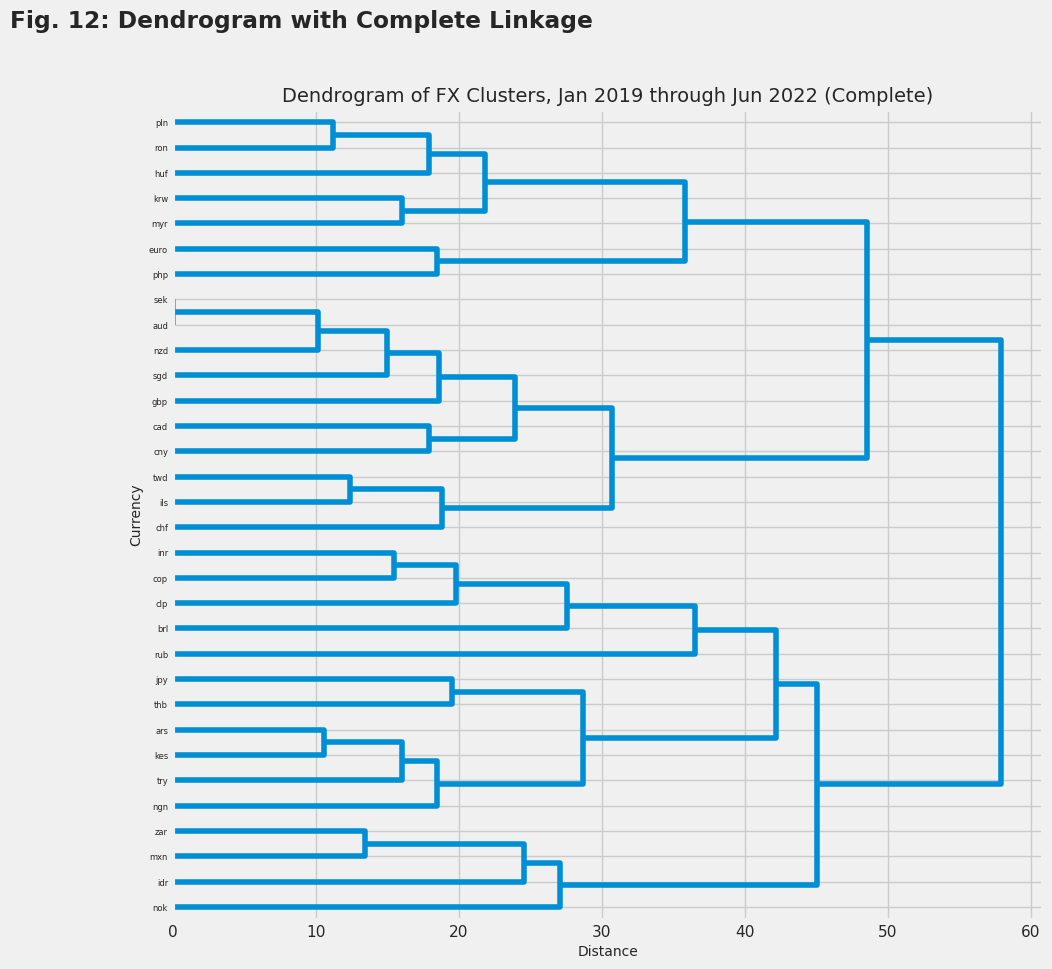

In [36]:
df_currencies_t = df_currencies.T

plt.figure(figsize=(10, 10))
plt.title(
    "Dendrogram of FX Clusters, Jan 2019 through Jun 2022 (Complete)", fontsize=14
)
plt.xlabel("Distance", fontsize=10)
plt.ylabel("Currency", fontsize=10)
plt.suptitle(
    "Fig. 12: Dendrogram with Complete Linkage",
    fontweight="bold",
    horizontalalignment="right",
)
dendrogram(
    hier_comp,
    orientation="right",
    #     leaf_rotation=90.,
    leaf_font_size=20,
    labels=df_currencies_t.index.values,
    color_threshold=3,
)
plt.yticks(fontsize=6)
plt.show()

## 5. Conclusion

In this lesson, we have studied and implemented hierarchical clustering. In the next lesson, we will focus on another unsupervised learning method that is used to reduce the number of variables in a dataset.

**References**
1. Murtagh, Fionn, and Pedro Contreras. "Algorithms for Hierarchical Clustering: An 
Overview." *Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery*, vol. 2, no. 1, 2012.
2. Murtagh, Fionn, and Pedro Contreras. "Algorithms for Hierarchical Clustering: An Overview, II." *Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery*, vol. 7, no. 6, 2017.
3. Murtagh, Fionn, and Pedro Contreras. "Methods of Hierarchical Clustering." *arXiv preprint*, arXiv:1105.0121, 2011.
4. Nielsen, Frank. "Hierarchical Clustering." *Introduction to HPC with MPI for Data Science*. Springer, 2016, pp. 195-211.

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
